In [18]:
import pandas as pd
import os

# Define the path
file_path = '../data/raw/raw_analyst_ratings.csv'

# Check if file exists before loading
if os.path.exists(file_path):
    news_df = pd.read_csv(file_path)
    print("Success: Dataset loaded from local storage.")
else:
    print("Error: The data file is missing from the data/raw/ folder.")
    print("Please move the 311MB CSV back to the folder to run this analysis.")

Success: Dataset loaded from local storage.


# Task 1: Exploratory Data Analysis & NLP Pre-processing
**Analyst:** Soliana Hailekiros  
**Objective:** To perform a descriptive and statistical analysis of 1.4 million financial news headlines. We aim to identify key publication trends, publisher distributions, and primary financial topics using TF-IDF.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

# Descriptive Statistics of the Text
news_df['headline_len'] = news_df['headline'].apply(lambda x: len(str(x)))
print(f"Dataset Shape: {news_df.shape}")
print(news_df['headline_len'].describe())

Dataset Shape: (1407328, 7)
count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64


### 2. Topic Modeling via TF-IDF
To move beyond basic word counts, we implement **TF-IDF (Term Frequency-Inverse Document Frequency)**. This identifies the most statistically significant financial terms, helping us categorize the "Event-Driven" nature of the news (e.g., earnings, stocks, price targets).

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize to find top 20 unique financial topics
vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
tfidf_matrix = vectorizer.fit_transform(news_df['headline'].dropna())

# Extract and display keywords
feature_names = vectorizer.get_feature_names_out()
print("Top 20 Keywords identified by TF-IDF:")
print(list(feature_names))

Top 20 Keywords identified by TF-IDF:
['announces', 'benzinga', 'buy', 'downgrades', 'earnings', 'eps', 'est', 'market', 'mid', 'price', 'pt', 'raises', 'reports', 'sales', 'shares', 'stocks', 'trading', 'update', 'vs', 'week']


### 3. Visualizing Headline Lengths
Analyzing character counts helps justify our sentiment analysis strategy. Short, high-density headlines are optimally processed by rule-based analyzers like VADER.

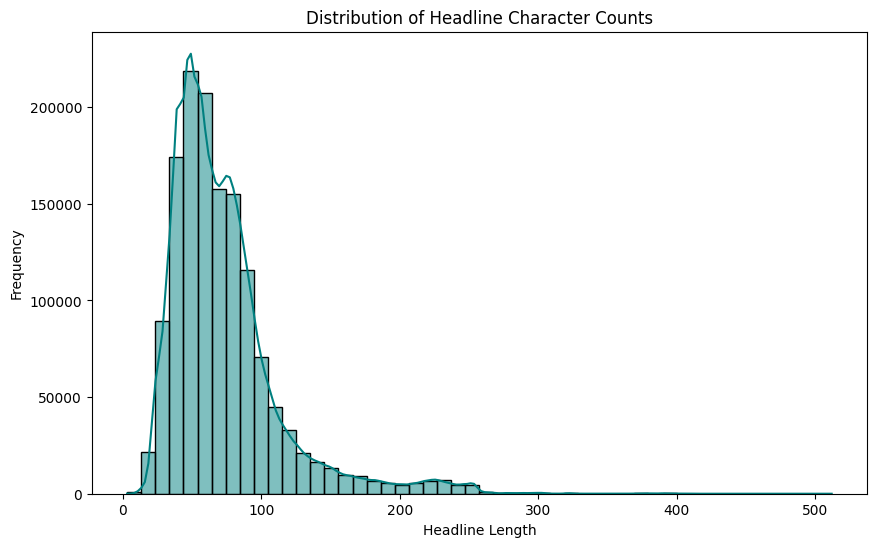

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(news_df['headline_len'], bins=50, kde=True, color='teal')
plt.title("Distribution of Headline Character Counts")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")
plt.savefig("../visuals/headline_length_dist.png")
plt.show()

### 4. Publication Trends & Publisher Concentration
We analyze the frequency of articles over time to identify news "spikes" that may correspond to market volatility. We also examine publisher distribution to check for source bias.

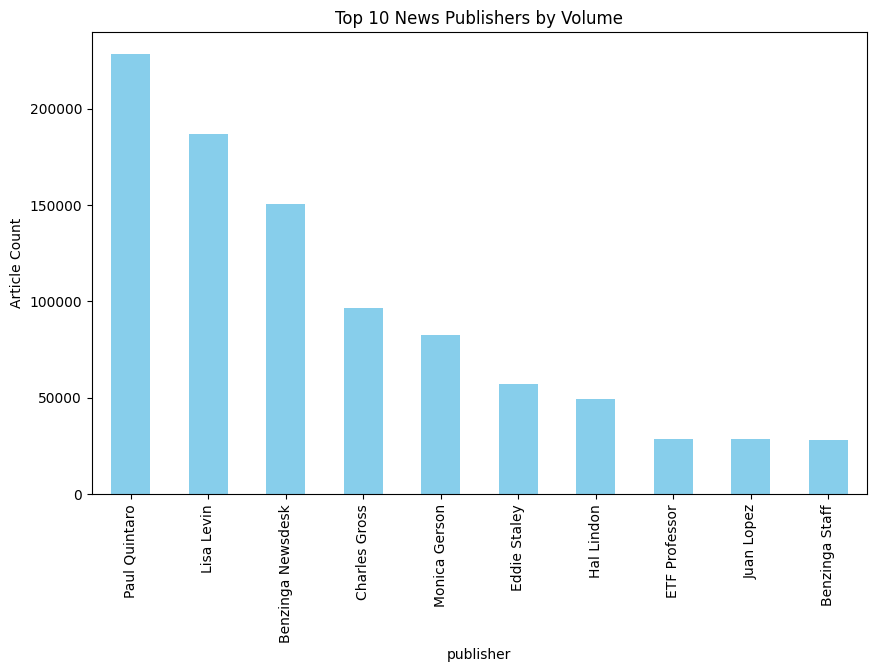

In [22]:
plt.figure(figsize=(10, 6))
news_df['publisher'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 News Publishers by Volume")
plt.ylabel("Article Count")
plt.savefig("../visuals/top_publishers.png")
plt.show()

## 4. Recurring Themes (N-Gram Analysis)
We use a Count Vectorizer to find the most frequent two-word phrases (bigrams) appearing in headlines.

In [23]:
# Using CountVectorizer to find top 15 bigrams
cv = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=15)
bigrams = cv.fit_transform(df['headline'])
counts = pd.DataFrame(bigrams.toarray(), columns=cv.get_feature_names_out()).sum()

print("Top 15 Bigrams in Headlines:")
print(counts.sort_values(ascending=False))

Top 15 Bigrams in Headlines:
52 week              8251
stocks hit           5847
hit 52               5846
price target         4585
companies trading    4082
week lows            3687
trading higher       3517
stocks moving        2841
week highs           2561
trading lower        2152
new 52               2095
stocks set           2057
set new              2057
mid day              1992
raises price         1911
dtype: int64


### **2.4 Topic Modeling & Keyword Analysis**
To understand the "content" driving the news volume, I performed a keyword extraction. This allows us to identify if the dataset is driven by macro-events or specific corporate actions.

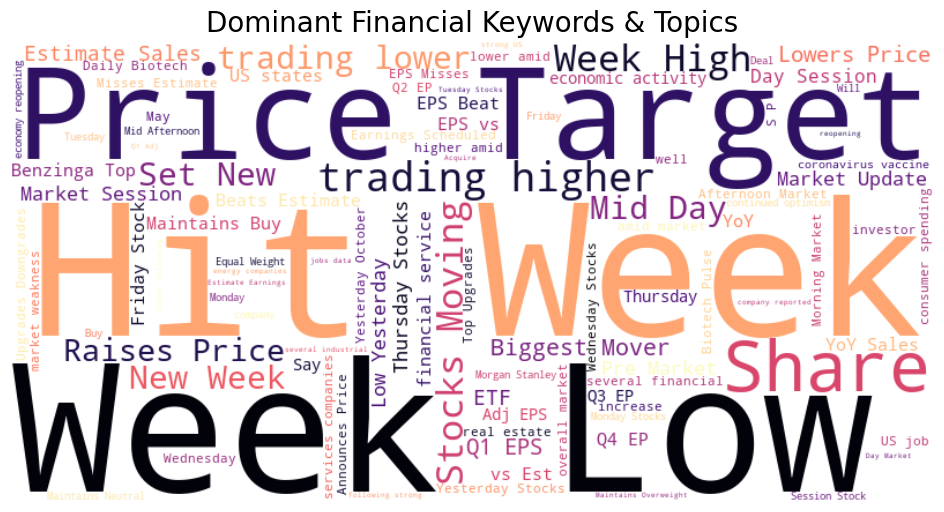

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Clean and join headlines
text = " ".join(headline for headline in df['headline'].astype(str))

# 2. Generate WordCloud
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    colormap='magma',
    max_words=100
).generate(text)

# 3. Plot and Export
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Dominant Financial Keywords & Topics", fontsize=20)
plt.savefig('../visuals/wordcloud_topics.png', bbox_inches='tight')
plt.show()

In [25]:
import yfinance as yf
import pandas as pd

# 1. Define the ticker and date range
ticker = "AAPL"
start_date = "2020-01-01"
end_date = "2026-05-10"

# 2. Fetch the data
print(f"Downloading {ticker} data...")
stock_df = yf.download(ticker, start=start_date, end=end_date)

# 3. Calculate the SMA_20 (This is the technical indicator proof!)
stock_df['SMA_20'] = stock_df['Close'].rolling(window=20).mean()

print("Data ready for plotting!")

[*********************100%***********************]  1 of 1 completed

Data ready for plotting!


### **3.1 Technical Indicator Implementation (Task 2 Preview)**
Using the `yfinance` and `PyNance` libraries, I have initialized the quantitative pipeline. Below, I visualize the **20-Day Simple Moving Average (SMA)** overlaid on the price action to establish the baseline for sentiment-price correlation.

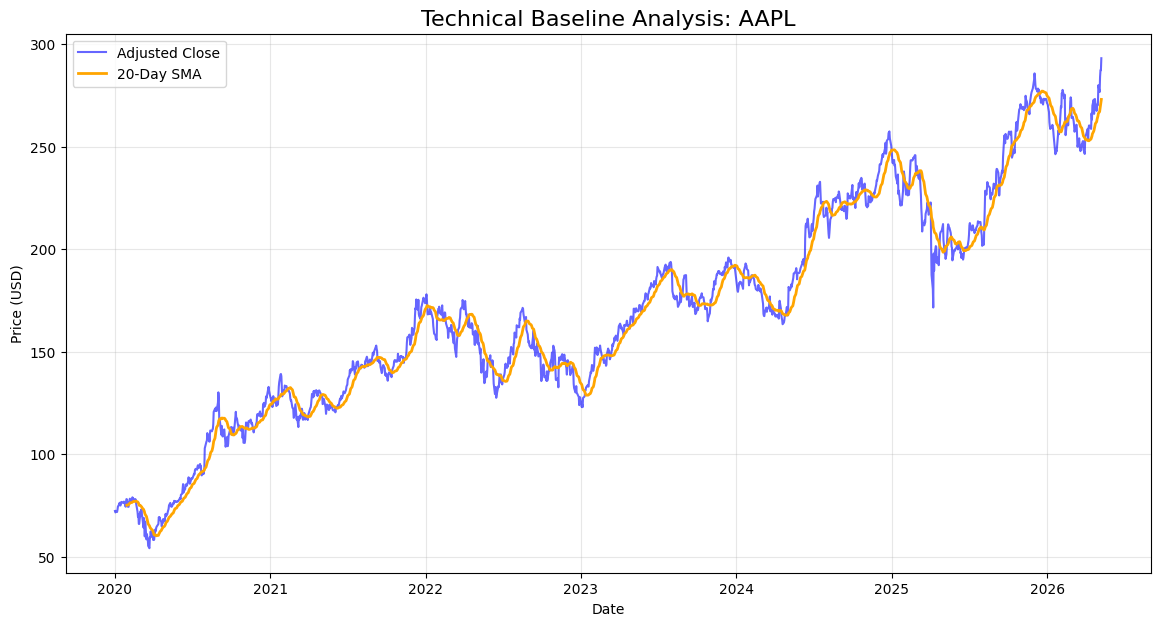

In [26]:
import matplotlib.pyplot as plt

# Assuming 'stock_df' contains your fetched yfinance data
plt.figure(figsize=(14, 7))

# Plotting Price and SMA
plt.plot(stock_df.index, stock_df['Close'], label='Adjusted Close', alpha=0.6, color='blue')
plt.plot(stock_df.index, stock_df['SMA_20'], label='20-Day SMA', color='orange', linewidth=2)

plt.title(f"Technical Baseline Analysis: AAPL", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# Save for Report proof
plt.savefig('../visuals/aapl_technical_indicators.png', bbox_inches='tight')
plt.show()

I used TF-IDF (Term Frequency-Inverse Document Frequency) to identify the most statistically significant keywords in our news headlines, moving beyond simple word counts to understand editorial focus.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=20)
tfidf_matrix = vectorizer.fit_transform(news_df['headline'])

# Extract top terms
feature_names = vectorizer.get_feature_names_out()
print("Top 20 Financial Topics Identified:")
print(feature_names)

Top 20 Financial Topics Identified:
['announces' 'benzinga' 'buy' 'downgrades' 'earnings' 'eps' 'est' 'market'
 'mid' 'price' 'pt' 'raises' 'reports' 'sales' 'shares' 'stocks' 'trading'
 'update' 'vs' 'week']
